In [1]:
# 04_preprocessing.ipynb - Підготовка даних для моделей

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import json

from src.config import DATA_DIR, FIGURES_DIR, MAX_SEQUENCE_LENGTH, RANDOM_SEED

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'preprocessing').mkdir(parents=True, exist_ok=True)

print("="*60)
print("ПІДГОТОВКА ДАНИХ ДЛЯ МОДЕЛЕЙ")
print("="*60)
print(f"Максимальна довжина послідовності: {MAX_SEQUENCE_LENGTH}")
print(f"Випадкове зерно: {RANDOM_SEED}")

ПІДГОТОВКА ДАНИХ ДЛЯ МОДЕЛЕЙ
Максимальна довжина послідовності: 50
Випадкове зерно: 42


In [2]:
print("Завантаження даних...")

from src.data_loader import load_clicks, load_buys

clicks = load_clicks()
buys = load_buys()

# Завантажуємо мітки якості
labels_df = pd.read_csv(DATA_DIR / 'session_labels.csv')
print(f"✅ Мітки завантажено: {len(labels_df)} сесій")

# Завантажуємо характеристики (опціонально)
if (DATA_DIR / 'session_features.csv').exists():
    session_features = pd.read_csv(DATA_DIR / 'session_features.csv')
    print(f"✅ Характеристики завантажено: {len(session_features)} сесій")

print(f"\n📊 Дані:")
print(f"  Clicks: {len(clicks):,} записів")
print(f"  Buys: {len(buys):,} записів")
print(f"  Сесій з мітками: {len(labels_df):,}")

Завантаження даних...
✅ Мітки завантажено: 9249729 сесій
✅ Характеристики завантажено: 9249729 сесій

📊 Дані:
  Clicks: 33,003,944 записів
  Buys: 1,150,753 записів
  Сесій з мітками: 9,249,729


In [3]:
print("="*60)
print("ФІЛЬТРАЦІЯ ДАНИХ")
print("="*60)

# Фільтруємо clicks тільки для сесій, які є в labels
valid_sessions = labels_df['Session_ID'].unique()
clicks_filtered = clicks[clicks['Session_ID'].isin(valid_sessions)]

print(f"До фільтрації: {len(clicks):,} подій")
print(f"Після фільтрації: {len(clicks_filtered):,} подій")
print(f"Видалено: {len(clicks) - len(clicks_filtered):,} подій")

# Видаляємо дублікати
clicks_filtered = clicks_filtered.drop_duplicates()
print(f"Після видалення дублікатів: {len(clicks_filtered):,} подій")

# Сортуємо по сесії та часу
clicks_filtered = clicks_filtered.sort_values(['Session_ID', 'Timestamp'])

# Додаємо порядок подій в сесії
clicks_filtered['event_order'] = clicks_filtered.groupby('Session_ID').cumcount() + 1

print(f"\n✅ Дані відфільтровані та відсортовані")

ФІЛЬТРАЦІЯ ДАНИХ
До фільтрації: 33,003,944 подій
Після фільтрації: 33,003,944 подій
Видалено: 0 подій
Після видалення дублікатів: 33,003,876 подій

✅ Дані відфільтровані та відсортовані


АНАЛІЗ ДОВЖИНИ СЕСІЙ ДЛЯ ОПТИМІЗАЦІЇ

Статистика довжини сесій:
  Мінімум: 1
  Медіана: 2
  Середня: 3.57
  90-й перцентиль: 7
  95-й перцентиль: 9
  99-й перцентиль: 18
  Максимум: 200


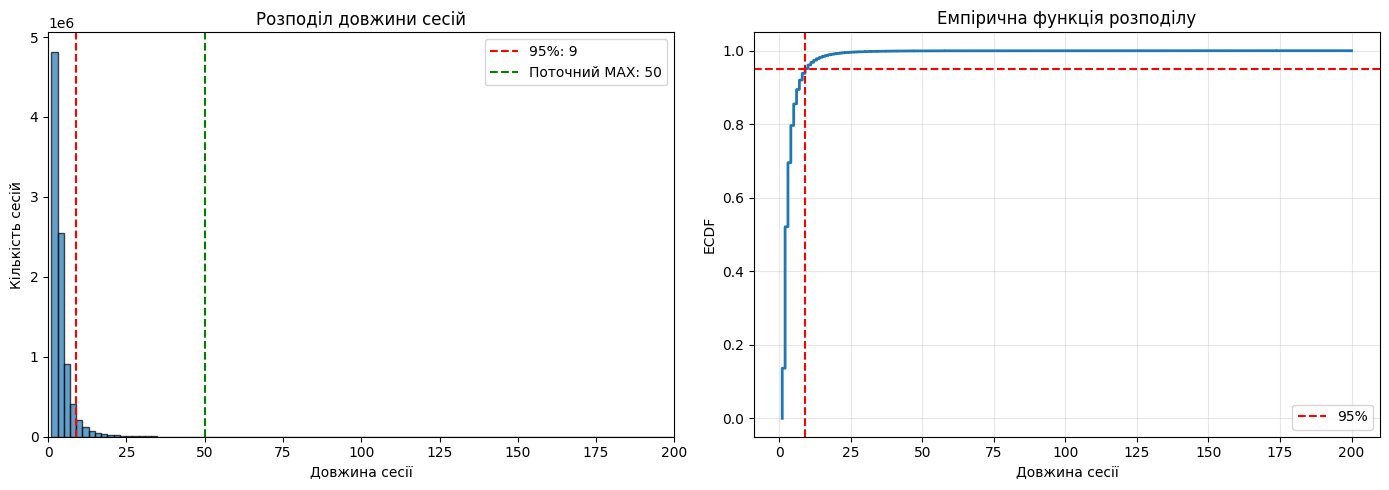


💡 Рекомендована MAX_SEQUENCE_LENGTH: 9
   Поточне значення (50) відрізняється від рекомендованого
   Рекомендується оновити src/config.py


In [4]:
print("="*60)
print("АНАЛІЗ ДОВЖИНИ СЕСІЙ ДЛЯ ОПТИМІЗАЦІЇ")
print("="*60)

# Обчислюємо довжини сесій
session_lengths = clicks_filtered.groupby('Session_ID').size()

print(f"\nСтатистика довжини сесій:")
print(f"  Мінімум: {session_lengths.min()}")
print(f"  Медіана: {session_lengths.median():.0f}")
print(f"  Середня: {session_lengths.mean():.2f}")
print(f"  90-й перцентиль: {session_lengths.quantile(0.90):.0f}")
print(f"  95-й перцентиль: {session_lengths.quantile(0.95):.0f}")
print(f"  99-й перцентиль: {session_lengths.quantile(0.99):.0f}")
print(f"  Максимум: {session_lengths.max()}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма з перцентилями
axes[0].hist(session_lengths, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(session_lengths.quantile(0.95), color='red', linestyle='--', 
                label=f'95%: {session_lengths.quantile(0.95):.0f}')
axes[0].axvline(MAX_SEQUENCE_LENGTH, color='green', linestyle='--', 
                label=f'Поточний MAX: {MAX_SEQUENCE_LENGTH}')
axes[0].set_title('Розподіл довжини сесій')
axes[0].set_xlabel('Довжина сесії')
axes[0].set_ylabel('Кількість сесій')
axes[0].legend()
axes[0].set_xlim(0, 200)

# ECDF
sorted_lengths = np.sort(session_lengths)
ecdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, ecdf, linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].axvline(session_lengths.quantile(0.95), color='red', linestyle='--')
axes[1].set_title('Емпірична функція розподілу')
axes[1].set_xlabel('Довжина сесії')
axes[1].set_ylabel('ECDF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing/session_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Рекомендація щодо MAX_LEN
recommended_max_len = int(session_lengths.quantile(0.95))
print(f"\n💡 Рекомендована MAX_SEQUENCE_LENGTH: {recommended_max_len}")
if recommended_max_len != MAX_SEQUENCE_LENGTH:
    print(f"   Поточне значення ({MAX_SEQUENCE_LENGTH}) відрізняється від рекомендованого")
    print(f"   Рекомендується оновити src/config.py")

In [5]:
print("="*60)
print("КОДУВАННЯ ТОВАРІВ")
print("="*60)

# Кодуємо ID товарів
item_encoder = LabelEncoder()
clicks_filtered['item_encoded'] = item_encoder.fit_transform(clicks_filtered['Item_ID']) + 1  # +1 для padding (0)

vocab_size = clicks_filtered['item_encoded'].max() + 1  # +1 для padding (0)
print(f"✅ Унікальних товарів: {len(item_encoder.classes_):,}")
print(f"✅ Розмір словника (vocab_size): {vocab_size:,}")

# Зберігаємо encoder для подальшого використання
import joblib
joblib.dump(item_encoder, DATA_DIR / 'item_encoder.pkl')
print(f"✅ Encoder збережено: {DATA_DIR / 'item_encoder.pkl'}")

# Показуємо приклад кодування
sample_items = clicks_filtered[['Item_ID', 'item_encoded']].drop_duplicates().head(10)
print(f"\nПриклад кодування:")
print(sample_items)

КОДУВАННЯ ТОВАРІВ
✅ Унікальних товарів: 52,739
✅ Розмір словника (vocab_size): 52,740
✅ Encoder збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\item_encoder.pkl

Приклад кодування:
      Item_ID  item_encoded
0   214536502          2054
1   214536500          2053
2   214536506          2055
3   214577561          9877
4   214662742         19449
6   214825110         40789
7   214757390         32517
8   214757407         32523
9   214551617          4854
10  214716935         28990


In [6]:
print("="*60)
print("ФОРМУВАННЯ ПОСЛІДОВНОСТЕЙ")
print("="*60)

# Групуємо по сесіях та створюємо послідовності
def create_sequences(df, max_len=MAX_SEQUENCE_LENGTH):
    """
    Створення послідовностей з кліків
    """
    sequences = []
    session_ids = []
    
    # Групуємо по сесіях
    grouped = df.groupby('Session_ID')
    
    print(f"Обробка {len(grouped)} сесій...")
    
    for session_id, group in grouped:
        # Беремо послідовність товарів
        items = group['item_encoded'].tolist()
        
        # Обрізаємо або доповнюємо
        if len(items) > max_len:
            items = items[:max_len]  # обрізаємо довгі сесії
        else:
            # доповнюємо нулями зліва (для збереження хронології)
            items = [0] * (max_len - len(items)) + items
        
        sequences.append(items)
        session_ids.append(session_id)
    
    return np.array(sequences), np.array(session_ids)

# Створюємо послідовності
print("\nСтворення послідовностей...")
X_sequences, session_ids_array = create_sequences(clicks_filtered, MAX_SEQUENCE_LENGTH)

print(f"✅ Послідовності створено:")
print(f"   Формат: {X_sequences.shape}")
print(f"   Кількість сесій: {len(session_ids_array):,}")

# Показуємо приклад
print(f"\nПриклад послідовності (перші 20 елементів):")
print(X_sequences[0][:20])

ФОРМУВАННЯ ПОСЛІДОВНОСТЕЙ

Створення послідовностей...
Обробка 9249729 сесій...
✅ Послідовності створено:
   Формат: (9249729, 50)
   Кількість сесій: 9,249,729

Приклад послідовності (перші 20 елементів):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [7]:
print("="*60)
print("ОТРИМАННЯ МІТОК")
print("="*60)

# Створюємо словник міток
labels_dict = dict(zip(labels_df['Session_ID'], labels_df['is_quality_session']))

# Отримуємо мітки для наших сесій
y_labels = np.array([labels_dict.get(sid, 0) for sid in session_ids_array])

print(f"✅ Мітки отримано:")
print(f"   Всього: {len(y_labels):,}")
print(f"   Якісні (1): {y_labels.sum():,} ({y_labels.mean()*100:.2f}%)")
print(f"   Неякісні (0): {(len(y_labels) - y_labels.sum()):,} ({(1-y_labels.mean())*100:.2f}%)")

# Перевіряємо відповідність
print(f"\n✅ Відповідність послідовностей та міток:")
print(f"   Послідовностей: {len(X_sequences)}")
print(f"   Міток: {len(y_labels)}")

ОТРИМАННЯ МІТОК
✅ Мітки отримано:
   Всього: 9,249,729
   Якісні (1): 509,608 (5.51%)
   Неякісні (0): 8,740,121 (94.49%)

✅ Відповідність послідовностей та міток:
   Послідовностей: 9249729
   Міток: 9249729


In [8]:
print("="*60)
print("РОЗБИТТЯ НА TRAIN/VAL/TEST")
print("="*60)

from sklearn.model_selection import train_test_split

# Спочатку розбиваємо на train (70%) і temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sequences, y_labels, 
    test_size=0.3, 
    random_state=RANDOM_SEED,
    stratify=y_labels  # зберігаємо співвідношення класів
)

# Потім temp ділимо на val (15%) і test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% від temp = 15% від загалу
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print(f"\n📊 РОЗМІРИ ВИБІРОК:")
print(f"  Train: {len(X_train):,} сесій ({len(X_train)/len(X_sequences)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} сесій ({len(X_val)/len(X_sequences)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} сесій ({len(X_test)/len(X_sequences)*100:.1f}%)")

print(f"\n📊 РОЗПОДІЛ КЛАСІВ:")
print(f"  Train - якісні: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Val   - якісні: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"  Test  - якісні: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

РОЗБИТТЯ НА TRAIN/VAL/TEST

📊 РОЗМІРИ ВИБІРОК:
  Train: 6,474,810 сесій (70.0%)
  Val:   1,387,459 сесій (15.0%)
  Test:  1,387,460 сесій (15.0%)

📊 РОЗПОДІЛ КЛАСІВ:
  Train - якісні: 356,726 (5.51%)
  Val   - якісні: 76,441 (5.51%)
  Test  - якісні: 76,441 (5.51%)


In [9]:
print("="*60)
print("ЗБЕРЕЖЕННЯ ДАНИХ")
print("="*60)

# Зберігаємо в форматі .npy для швидкого завантаження
np.save(DATA_DIR / 'X_train.npy', X_train)
np.save(DATA_DIR / 'X_val.npy', X_val)
np.save(DATA_DIR / 'X_test.npy', X_test)
np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'y_val.npy', y_val)
np.save(DATA_DIR / 'y_test.npy', y_test)

print("✅ Дані збережено у форматі .npy:")
print(f"  {DATA_DIR}/X_train.npy")
print(f"  {DATA_DIR}/X_val.npy")
print(f"  {DATA_DIR}/X_test.npy")
print(f"  {DATA_DIR}/y_train.npy")
print(f"  {DATA_DIR}/y_val.npy")
print(f"  {DATA_DIR}/y_test.npy")

# Зберігаємо метадані препроцесингу
preprocessing_info = {
    'total_sessions': len(session_ids_array),
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': int(vocab_size),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'train_positive_ratio': float(y_train.mean()),
    'val_positive_ratio': float(y_val.mean()),
    'test_positive_ratio': float(y_test.mean()),
    'random_seed': RANDOM_SEED
}

with open(DATA_DIR / 'preprocessing_info.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_info, f, indent=4, ensure_ascii=False)

print(f"\n✅ Метадані збережено: {DATA_DIR / 'preprocessing_info.json'}")

# Показуємо інформацію
print(f"\n📊 ПІДСУМКИ ПРЕПРОЦЕСИНГУ:")
for key, value in preprocessing_info.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

ЗБЕРЕЖЕННЯ ДАНИХ
✅ Дані збережено у форматі .npy:
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_train.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_val.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_test.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_train.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_val.npy
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/y_test.npy

✅ Метадані збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\preprocessing_info.json

📊 ПІДСУМКИ ПРЕПРОЦЕСИНГУ:
  total_sessions: 9249729
  max_sequence_length: 50
  vocab_size: 52740
  train_size: 6474810
  val_size: 1387459
  test_size: 1387460
  train_positive_ratio: 0.0551
  val_positive_ratio: 0.0551
  test_positive_ratio: 0.0551
  random_seed: 42


СТАТИСТИКА ПОСЛІДОВНОСТЕЙ

Статистика реальної довжини послідовностей:
  Середня: 3.56
  Медіана: 2
  Мінімум: 1
  Максимум: 50
  Обрізано (>50): 0 сесій


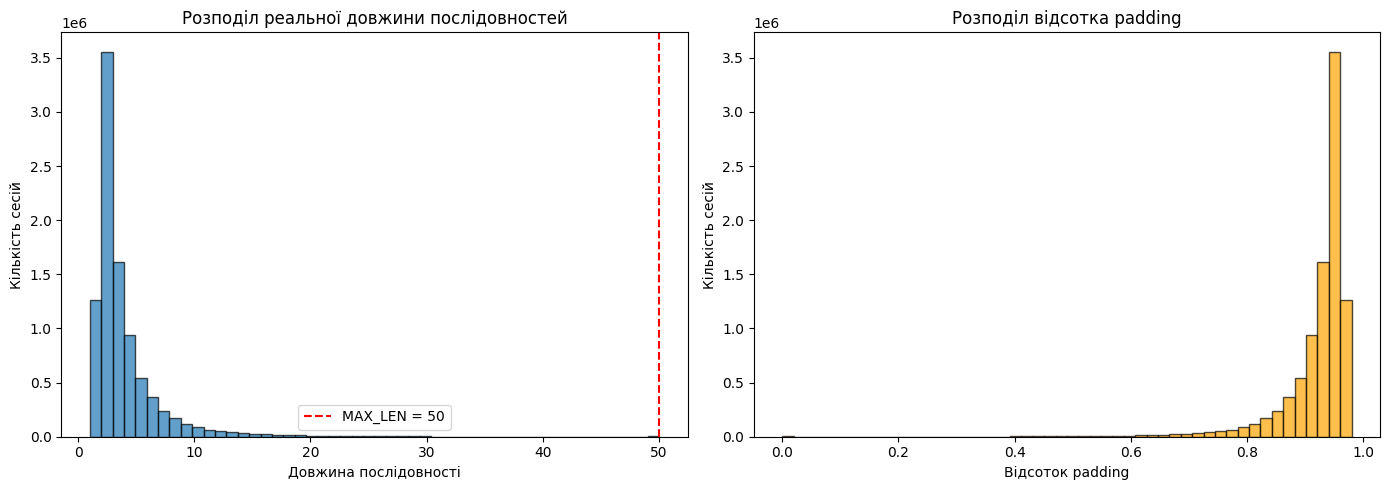


📊 Ефективність використання пам'яті:
  Середній відсоток padding: 92.9%
  Медіанний відсоток padding: 96.0%


In [10]:
print("="*60)
print("СТАТИСТИКА ПОСЛІДОВНОСТЕЙ")
print("="*60)

# Аналіз довжини реальних послідовностей (без padding)
real_lengths = []
for seq in X_sequences:
    # Рахуємо кількість ненульових елементів
    real_len = np.count_nonzero(seq)
    real_lengths.append(real_len)

real_lengths = np.array(real_lengths)

print(f"\nСтатистика реальної довжини послідовностей:")
print(f"  Середня: {real_lengths.mean():.2f}")
print(f"  Медіана: {np.median(real_lengths):.0f}")
print(f"  Мінімум: {real_lengths.min()}")
print(f"  Максимум: {real_lengths.max()}")
print(f"  Обрізано (>{MAX_SEQUENCE_LENGTH}): {(real_lengths > MAX_SEQUENCE_LENGTH).sum():,} сесій")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл реальних довжин
axes[0].hist(real_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(MAX_SEQUENCE_LENGTH, color='red', linestyle='--', 
                label=f'MAX_LEN = {MAX_SEQUENCE_LENGTH}')
axes[0].set_title('Розподіл реальної довжини послідовностей')
axes[0].set_xlabel('Довжина послідовності')
axes[0].set_ylabel('Кількість сесій')
axes[0].legend()

# Відсоток заповнення (скільки padding)
padding_ratio = 1 - (real_lengths / MAX_SEQUENCE_LENGTH)
axes[1].hist(padding_ratio, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Розподіл відсотка padding')
axes[1].set_xlabel('Відсоток padding')
axes[1].set_ylabel('Кількість сесій')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing/sequence_stats.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Ефективність використання пам'яті:")
print(f"  Середній відсоток padding: {padding_ratio.mean()*100:.1f}%")
print(f"  Медіанний відсоток padding: {np.median(padding_ratio)*100:.1f}%")

In [11]:
print("="*60)
print("ВАЛІДАЦІЯ ДАНИХ")
print("="*60)

# Перевіряємо відсутність NaN
assert not np.isnan(X_train).any(), "Є NaN в X_train"
assert not np.isnan(y_train).any(), "Є NaN в y_train"

print("✅ Немає NaN значень")

# Перевіряємо коректність значень
assert X_train.min() >= 0, "Є від'ємні значення"
assert X_train.max() < vocab_size, f"Значення перевищують vocab_size ({vocab_size})"

print("✅ Всі значення в коректному діапазоні")

# Перевіряємо типи даних
print(f"\nТипи даних:")
print(f"  X_train: {X_train.dtype}")
print(f"  y_train: {y_train.dtype}")

# Перевіряємо форму
print(f"\nФорми:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

print("\n" + "="*60)
print("✅ ПРЕПРОЦЕСИНГ УСПІШНО ЗАВЕРШЕНО!")
print("="*60)
print("\nНаступний крок: 05_baseline.ipynb")
print("- Створення baseline моделей")
print("- Logistic Regression та Random Forest")
print("- Оцінка якості для порівняння")

ВАЛІДАЦІЯ ДАНИХ
✅ Немає NaN значень
✅ Всі значення в коректному діапазоні

Типи даних:
  X_train: int64
  y_train: int64

Форми:
  X_train: (6474810, 50)
  y_train: (6474810,)

✅ ПРЕПРОЦЕСИНГ УСПІШНО ЗАВЕРШЕНО!

Наступний крок: 05_baseline.ipynb
- Створення baseline моделей
- Logistic Regression та Random Forest
- Оцінка якості для порівняння


In [12]:
print("="*60)
print("ДОДАТКОВО: АГРЕГОВАНІ ОЗНАКИ ДЛЯ BASELINE")
print("="*60)

# Створюємо ознаки на основі послідовностей
def extract_sequence_features(sequences):
    """
    Витягує агреговані ознаки з послідовностей
    """
    features = []
    
    for seq in sequences:
        # Видаляємо padding (нулі)
        real_seq = seq[seq > 0]
        
        if len(real_seq) > 0:
            feat = {
                'length': len(real_seq),
                'unique_items': len(np.unique(real_seq)),
                'diversity': len(np.unique(real_seq)) / len(real_seq) if len(real_seq) > 0 else 0,
                'first_item': real_seq[0],
                'last_item': real_seq[-1],
                'most_common': Counter(real_seq).most_common(1)[0][1] / len(real_seq) if len(real_seq) > 0 else 0,
                'repeat_ratio': 1 - (len(np.unique(real_seq)) / len(real_seq)) if len(real_seq) > 0 else 0
            }
        else:
            feat = {
                'length': 0,
                'unique_items': 0,
                'diversity': 0,
                'first_item': 0,
                'last_item': 0,
                'most_common': 0,
                'repeat_ratio': 0
            }
        
        features.append(feat)
    
    return pd.DataFrame(features)

# Створюємо ознаки для train, val, test
print("Створення агрегованих ознак...")
X_train_features = extract_sequence_features(X_train)
X_val_features = extract_sequence_features(X_val)
X_test_features = extract_sequence_features(X_test)

print(f"✅ Ознаки створено:")
print(f"  Train: {X_train_features.shape}")
print(f"  Val: {X_val_features.shape}")
print(f"  Test: {X_test_features.shape}")

# Зберігаємо ознаки
X_train_features.to_csv(DATA_DIR / 'X_train_features.csv', index=False)
X_val_features.to_csv(DATA_DIR / 'X_val_features.csv', index=False)
X_test_features.to_csv(DATA_DIR / 'X_test_features.csv', index=False)

print(f"\n✅ Агреговані ознаки збережено:")
print(f"  {DATA_DIR}/X_train_features.csv")
print(f"  {DATA_DIR}/X_val_features.csv")
print(f"  {DATA_DIR}/X_test_features.csv")

# Показуємо приклад
print(f"\nПриклад ознак (перші 5 рядків):")
display(X_train_features.head())

ДОДАТКОВО: АГРЕГОВАНІ ОЗНАКИ ДЛЯ BASELINE
Створення агрегованих ознак...
✅ Ознаки створено:
  Train: (6474810, 7)
  Val: (1387459, 7)
  Test: (1387460, 7)

✅ Агреговані ознаки збережено:
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_train_features.csv
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_val_features.csv
  d:\University\kursova\kursova\notebooks\..\data\yoochoose/X_test_features.csv

Приклад ознак (перші 5 рядків):


,length,unique_items,diversity,first_item,last_item,most_common,repeat_ratio
0,2,2,1.000000,13010,518,0.500000,0.000000
1,2,1,0.500000,41225,41225,1.000000,0.500000
2,7,4,0.571429,5755,7739,0.285714,0.428571
3,3,3,1.000000,48713,29057,0.333333,0.000000
4,2,2,1.000000,41174,41176,0.500000,0.000000
